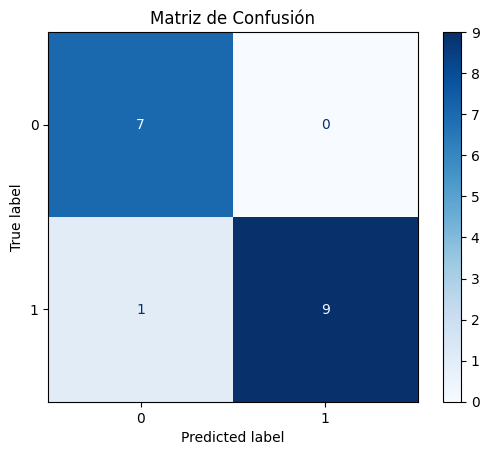

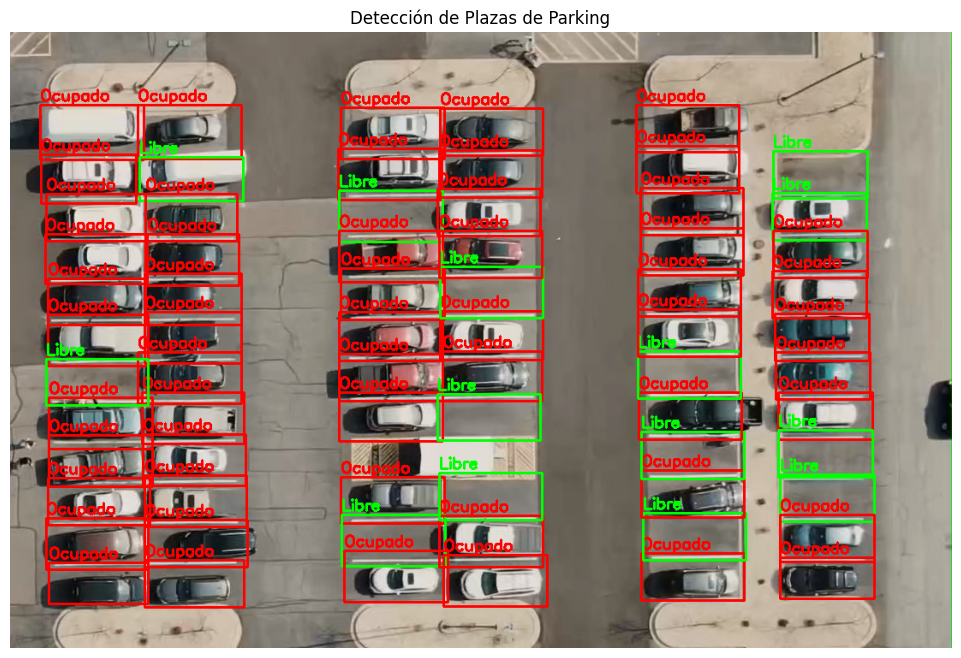

In [37]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Librería para cargar las imágenes
import glob
# Librería para cargar las coordenadas de las plazas de parking desde XML
import xml.etree.ElementTree as ET

parkings_ocupados = []
parkings_libres = []
etiquetas= []

def tratar_img(img_a_tratar):
    img = cv2.imread(img_a_tratar)
    img_parking_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_parking_gray_inv = cv2.bitwise_not(img_parking_gray)
    img_parking_128x128 = cv2.resize(img_parking_gray_inv, (128,128))
    X_aplanado = img_parking_128x128.reshape(16384)
    X_normalizado = X_aplanado / 255
    return X_normalizado

# Leemos las imágenes de entrenamiento
for img in glob.glob('./images/parking_ocupado/*.png'):
    parkings_ocupados.append(tratar_img(img))
    # Llenamos las etiquetas de 1 (ocupado) por cada foto de parking ocupado
    etiquetas.append(1)

for img in glob.glob('./images/parking_vacio/*.png'):
    parkings_libres.append(tratar_img(img))
    # Llenamos las etiquetas de 0 (libre) por cada foto de parking libre
    etiquetas.append(0)

imagenes_entrenamiento = parkings_ocupados + parkings_libres
# Dividimos el dataset en entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(imagenes_entrenamiento, etiquetas, test_size = 0.2, train_size = 0.8, random_state = 42, shuffle=True)
# Creamos el modelo KNN
mi_ia = KNeighborsClassifier(n_neighbors = 3)

# Entrenamos la IA pasándole los datos de entrenamiento (X_train, y_train)
mi_ia.fit(X_train, y_train)

predicciones = mi_ia.predict(X_test)

# Dibujamos la matriz
matriz = confusion_matrix(y_test, predicciones)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión")
plt.show()

# Cargamos una imagen de parking y las coordenadas de plazas desde XML
img_parking = cv2.imread('./images/parkings_ejemplos/carpark_frame.png')
img_parking_gray = cv2.cvtColor(img_parking, cv2.COLOR_BGR2GRAY)

# Cargamos las coordenadas de las plazas de parking desde el XML
tree = ET.parse('./xml/carpark_coords.xml')
root = tree.getroot()

# Recorremos cada objeto (plaza de parking) del XML
for obj in root.findall('object'):
    bbox = obj.find('bndbox')
    if bbox is None:
        continue

    xmin = int(bbox.find('xmin').text)
    ymin = int(bbox.find('ymin').text)
    xmax = int(bbox.find('xmax').text)
    ymax = int(bbox.find('ymax').text)

    x, y, w, h = xmin, ymin, xmax - xmin, ymax - ymin

    # Recortamos la imagen de cada plaza de parking usando las coordenadas del XML
    parking_recortado = img_parking_gray[y:y+h, x:x+w]

    # Procesamos la imagen recortada para que tenga el mismo formato que las imágenes de entrenamiento
    parking_recortado_128x128 = cv2.resize(parking_recortado, (128,128))
    parking_recortado_128x128_inv = cv2.bitwise_not(parking_recortado_128x128)
    parking_recortado_128x128_inv_aplanado = parking_recortado_128x128_inv.reshape(16384)
    parking_recortado_final = parking_recortado_128x128_inv_aplanado / 255

    # Hacemos la predicción con la IA para cada plaza de parking recortada
    prediccion = mi_ia.predict([parking_recortado_final])
    if prediccion[0] == 1:
        color = (0, 0, 255)  # Rojo para ocupado
        texto = "Ocupado"
    else:
        color = (0, 255, 0)  # Verde para libre
        texto = "Libre"

    cv2.rectangle(img_parking, (x, y), (x + w, y + h), color, 2)
    cv2.putText(img_parking, texto, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(img_parking, cv2.COLOR_BGR2RGB))
plt.title('Detección de Plazas de Parking')
plt.axis('off')
plt.show()

In [ ]:
# Funciones

def cargar_coordenadas_plazas_desde_xml(ruta_xml):
    tree = ET.parse(ruta_xml)
    root = tree.getroot()
    coordenadas = []
    for i, obj in enumerate(root.findall('object'), start=1):
        bbox = obj.find('bndbox')
        if bbox is None:
            continue

        xmin = int(bbox.find('xmin').text)
        ymin = int(bbox.find('ymin').text)
        xmax = int(bbox.find('xmax').text)
        ymax = int(bbox.find('ymax').text)
        coordenadas.append((i, xmin, ymin, xmax, ymax))
    return coordenadas

def tratar_recorte_video(recorte_bgr):
    # Procesamos el recorte 
    recorte_gray = cv2.cvtColor(recorte_bgr, cv2.COLOR_BGR2GRAY)
    recorte_128x128 = cv2.resize(recorte_gray, (128, 128))
    recorte_128x128_inv = cv2.bitwise_not(recorte_128x128)
    recorte_aplanado = recorte_128x128_inv.reshape(16384)
    recorte_final = recorte_aplanado.astype(np.float32) / 255.0
    return recorte_final

def pintar_plazas_en_frame(frame_bgr, coordenadas):
    frame_resultado = frame_bgr.copy()
    entradas = []
    metadatos = []

    for i, xmin, ymin, xmax, ymax in coordenadas:
        x, y, w, h = xmin, ymin, xmax - xmin, ymax - ymin
        parking_recortado = frame_bgr[y:y+h, x:x+w]

        if parking_recortado.size == 0:
            continue

        entradas.append(tratar_recorte_video(parking_recortado))
        metadatos.append((i, x, y, w, h))

    predicciones_frame = mi_ia.predict(np.asarray(entradas, dtype=np.float32))

    resultados = []
    for (i, x, y, w, h), prediccion in zip(metadatos, predicciones_frame):
        if prediccion == 1:
            color = (0, 0, 255)  # Rojo para ocupado
            texto = 'Ocupado'
        else:
            color = (0, 255, 0)  # Verde para libre
            texto = 'Libre'

        cv2.rectangle(frame_resultado, (x, y), (x + w, y + h), color, 2)
        cv2.putText(frame_resultado, texto, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
        resultados.append({'plaza': i, 'prediccion': texto})

    return frame_resultado, resultados


In [12]:
import os
from IPython.display import Video, display

COORDS_PATH = './xml/carpark_coords.xml'
RUTA_VIDEO = './videos/carpark.mp4'
RUTA_VIDEO_SALIDA = './videos/carpark_resultado.mp4'


# Preparamos las coordenadas de las plazas a partir del XML
coordenadas_plazas = cargar_coordenadas_plazas_desde_xml(COORDS_PATH)

# Definimos la ruta del vídeo de entrada y del vídeo de salida
os.makedirs('./videos', exist_ok=True)

# Cargamos el vídeo original
cap = cv2.VideoCapture(RUTA_VIDEO)
if not cap.isOpened():
    raise ValueError('No se pudo abrir el vídeo.')

fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
ancho = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
alto = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Creamos el escritor para guardar el vídeo con las detecciones
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(RUTA_VIDEO_SALIDA, fourcc, fps, (ancho, alto))
if not writer.isOpened():
    cap.release()
    raise ValueError('No se pudo crear el vídeo de salida.')

frame_previo = None
resultados = []
frames_procesados = 0

# Recorremos todos los frames del vídeo y aplicamos la detección a cada uno
while True:
    ok, frame = cap.read()
    if not ok:
        break

    frame_resultado, resultados = pintar_plazas_en_frame(frame, coordenadas_plazas)

    if frame_previo is None:
        frame_previo = frame_resultado.copy()

    writer.write(frame_resultado)
    frames_procesados += 1

cap.release()
writer.release()

ocupadas = [r for r in resultados if r['prediccion'] == 'Ocupado']
libres = [r for r in resultados if r['prediccion'] == 'Libre']
ruta_video_generada = os.path.abspath(RUTA_VIDEO_SALIDA)

print(f"Vídeo usado: {os.path.abspath(RUTA_VIDEO)}")
print(f"Frames procesados: {frames_procesados}")
print(f"Vídeo generado: {ruta_video_generada}")
print(f"Plazas libres en el último frame: {len(libres)}")
print(f"Plazas ocupadas en el último frame: {len(ocupadas)}")

plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(frame_previo, cv2.COLOR_BGR2RGB))
plt.title('Primer frame del vídeo con detecciones')
plt.axis('off')
plt.show()

display(Video(ruta_video_generada, embed=True, html_attributes='controls width=960'))

error: OpenCV(4.11.0) :-1: error: (-5:Bad argument) in function 'imread'
> Overload resolution failed:
>  - Expected 'filename' to be a str or path-like object
>  - Expected 'filename' to be a str or path-like object
>  - Expected 'filename' to be a str or path-like object
